# Stock Market Data Analysis
Stock Market Analysis and Prediction is the project related to Exploratory data analysis(EDA), Data visualization and Predictive analysis using data, provided by The Investors Exchange (IEX). I looked at real-time financial data from the stock market. I have used python libraries to get stock information, visualize different aspects of it, and finally I worked at a few ways of analyzing the risk of a stock, based on its previous performance history. I have also used statistical method called $ Monte \ Carlo \ Method $ to predict future stock prices.


We'll be answering the following questions along the way:

What was the change in price of the stock over time? \
What was the daily return of the stock on average? \
What was the moving average of the various stocks? \
What was the correlation between different stocks' closing prices? \
What was the correlation between different stocks' daily returns? \
How much value do we put at risk by investing in a particular stock? \
How can we attempt to predict future stock behavior? \
Basic Analysis of Stock Information 

In this section we'll go over how to handle requesting stock information with pandas, and how to analyze basic attributes of a stock.

In [19]:
import pandas as pd

In [20]:
import numpy as np

In [21]:
from pandas import Series, DataFrame

In [22]:
import matplotlib.pyplot as plt

In [23]:
import seaborn as sns

In [24]:
sns.set_style("whitegrid")

In [25]:
%matplotlib inline 
##icchina prathi code cell ki ventane kindhane graph display chesthundhi.. 
## idhi lekapothe graph vere window lo ocche chance undhi..
## Ee line only ipynb lo ne untadhi anta


In [26]:
#to get rid of import error of pandas_datareader 
pd.core.common.is_list_like = pd.api.types.is_list_like


In [29]:
# For reading stock data from The Investors Exchange (IEX)
import yfinance as yf

In [30]:
# For time stamps
from datetime import datetime

In [31]:
# For division
from __future__ import division

In [32]:
# Let's use these stocks for our analysis
tech_list = ['AAPL','GOOG','MSFT','AMZN']

In [33]:
# Set up End and Start times for data grab
end = datetime.now()
start = datetime(end.year - 1,end.month,end.day)

In [37]:
def DataReader(symbol, data_source=None, start=None, end=None):
    """
    Mimic pandas_datareader's DataReader function using yfinance
    """
    if data_source and data_source.lower() != 'yahoo':
        print(f"Warning: {data_source} not supported, using yahoo finance instead")
    
    return yf.download(symbol, start=start, end=end)

In [39]:
for stock in tech_list:
    # Download stock data using yfinance
    data = yf.download(stock, start=start, end=end)
    
    # Set DataFrame as the Stock Ticker (creates variables AAPL, GOOG, etc.)
    globals()[stock] = data
    
    print(f"Downloaded {stock} data with {len(data)} rows")

[*********************100%***********************]  1 of 1 completed


Downloaded AAPL data with 251 rows


[*********************100%***********************]  1 of 1 completed


Downloaded GOOG data with 251 rows


[*********************100%***********************]  1 of 1 completed


Downloaded MSFT data with 251 rows


[*********************100%***********************]  1 of 1 completed

Downloaded AMZN data with 251 rows


In [40]:
AAPL.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-10,226.492844,235.135185,223.246996,234.517865,72071200
2025-03-11,219.881668,224.859971,216.506379,222.838781,76137400
2025-03-12,216.038406,220.787711,213.977397,219.184697,62547500
2025-03-13,208.770081,215.899013,207.515554,215.012876,61368300
2025-03-14,212.563553,213.021548,208.670517,210.333268,60107600


In [41]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,236.492463,239.067323,233.922596,236.403160,5.372340e+07
std,29.262762,29.140355,29.418294,29.389084,2.346508e+07
min,171.671799,189.514035,168.475737,171.203815,2.841115e+06
25%,209.377846,211.402704,207.277787,209.377843,4.007355e+07
50%,233.904175,237.736866,232.916053,236.549127,4.749050e+07
75%,264.264999,267.059937,261.375955,263.544998,5.682820e+07
max,285.922455,288.350192,283.035157,285.932471,1.843959e+08


In [42]:
AAPL.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-10 to 2026-03-09
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [44]:
AAPL

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-10,226.492844,235.135185,223.246996,234.517865,72071200
2025-03-11,219.881668,224.859971,216.506379,222.838781,76137400
2025-03-12,216.038406,220.787711,213.977397,219.184697,62547500
2025-03-13,208.770081,215.899013,207.515554,215.012876,61368300
2025-03-14,212.563553,213.021548,208.670517,210.333268,60107600
...,...,...,...,...,...
2026-03-03,263.750000,265.559998,260.130005,263.480011,38568900
2026-03-04,262.519989,266.149994,261.420013,264.649994,39803100


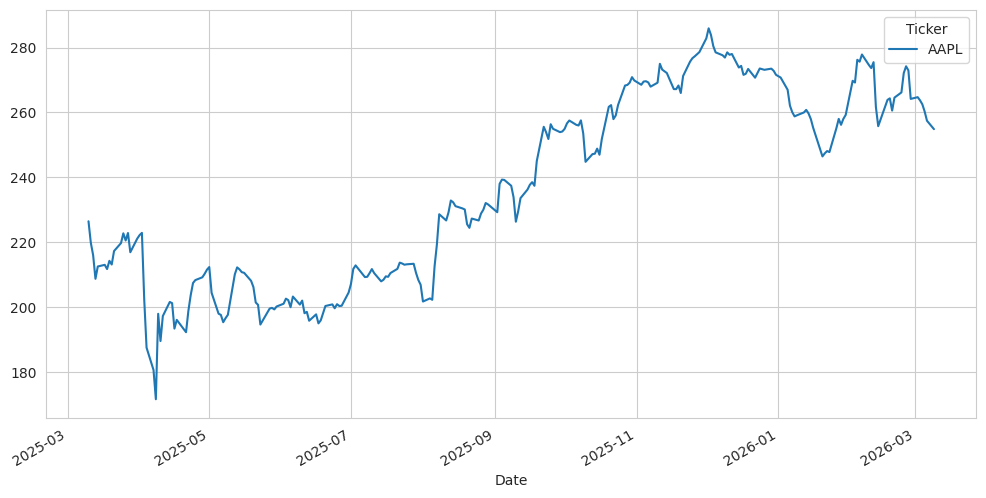

In [47]:
AAPL["Close"].plot(legend=True, figsize=(12,6))
plt.show()

It's the Closoing price of AAPL each day from last year

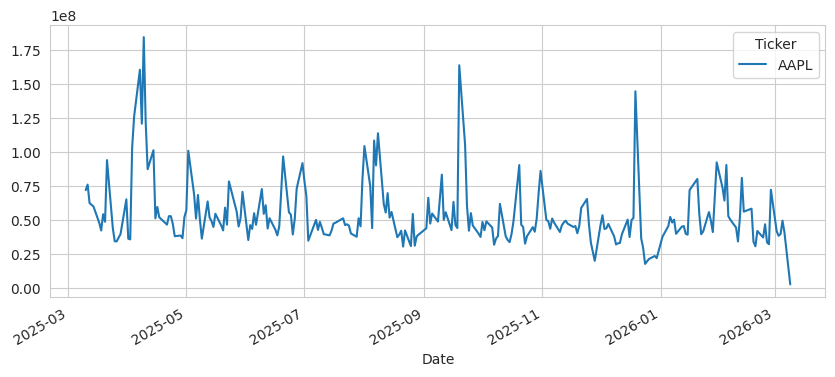

In [48]:
# Now let's plot the total volume of stock being traded each day over the past 5 years
AAPL['Volume'].plot(legend=True,figsize=(10,4))
plt.show()

It is the Volume Traded by AAPL each day.

Now, Let's calculate `Moving Average - MA` for the stock 

A `Moving Average (MA)` is a widely used indicator in technical analysis that helps smooth out price action by filtering out the “noise” from random price fluctuations. It is a trend-following, or lagging, indicator because it is based on past prices.

In [50]:
# Let's go ahead and plot out several moving averages
ma_day = [10,20,50]

for ma in ma_day:
    column_name = "MA for %s days" %(str(ma))
    AAPL[column_name]=pd.DataFrame.rolling(AAPL['Close'],ma).mean()

Now let's go ahead and plot all the additional Moving Averages

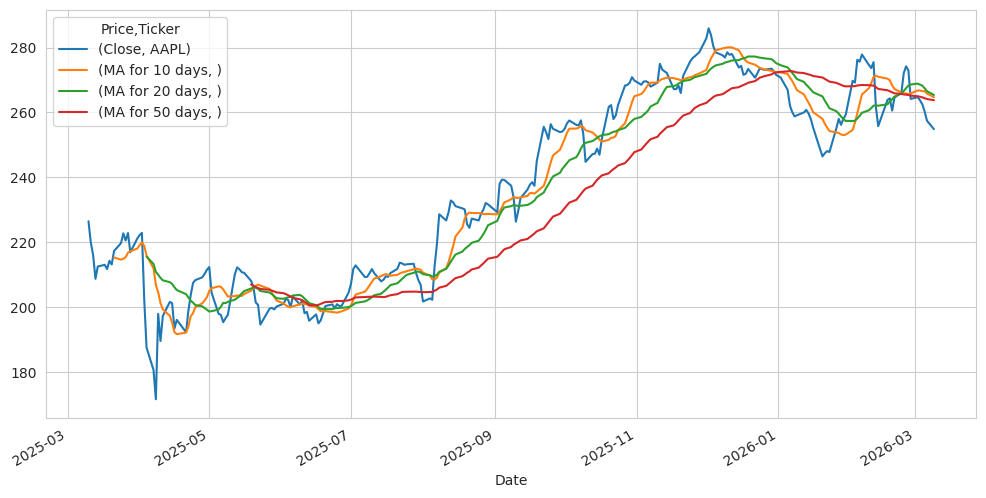

In [51]:
AAPL[['Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(subplots=False,figsize=(12,6))
plt.show()

### Daily Return Analysis
Now that we've done some baseline analysis, let's go ahead and dive a little deeper. We're now going to analyze the risk of the stock. In order to do so we'll need to take a closer look at the daily changes of the stock, and not just its absolute value. Let's go ahead and use pandas to retrieve the daily returns for the Apple stock.


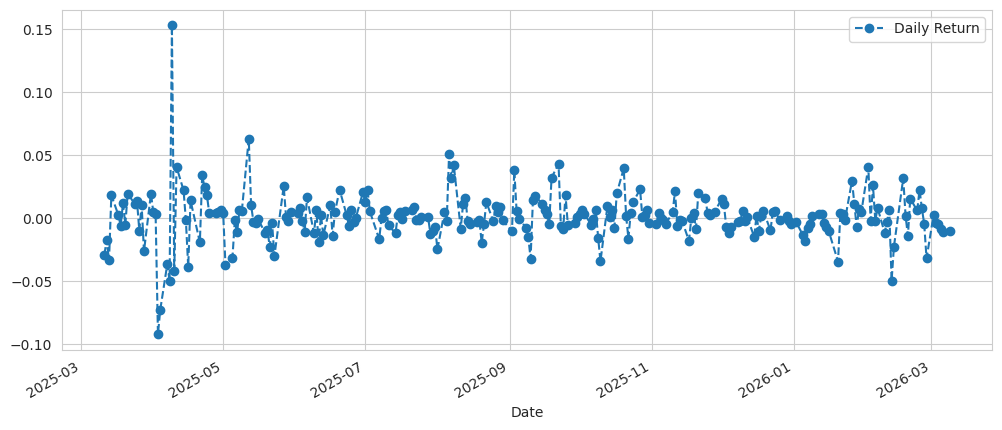

In [52]:
# use pct_change to find the percent change for each day
AAPL['Daily Return'] = AAPL['Close'].pct_change()
# plot the daily return percentage
AAPL['Daily Return'].plot(figsize=(12,5),legend=True,linestyle='--',marker='o')
plt.show()

Now let's get an overall look at the average daily return using a histogram. We'll use seaborn to create both a histogram and kde plot on the same figure.